In [34]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") # Use GPU if available
device

device(type='cuda', index=0)

In [77]:
words = open('names.txt', 'r').read().splitlines()

chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
#print total number of words and characters in the vocabulary
print(f'{len(words)} words, {len(chars)} unique characters')
block_size = 3
batch_size = 32*16
n_embd = 10
n_hidden = 100
n_out = len(stoi)
print(f'{n_out} output classes, (unique characters) (including padding character)')
#print out hyperparameters
print(f'block_size: {block_size}, batch_size: {batch_size}, n_embd: {n_embd}, n_hidden: {n_hidden}')


32033 words, 26 unique characters
27 output classes, (unique characters) (including padding character)
block_size: 3, batch_size: 512, n_embd: 10, n_hidden: 100


In [78]:
def build_dataset(words):
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append
    
    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    print('X:', X.shape, '\tY:', Y.shape)
    return X,Y

random.seed(42)          # for reproducibility
random.shuffle(words)    # words is just the bare list of all names, from wayyy above

n1 = int(0.8*len(words)) # index at 80% of all words (rounded for integer indexing)
n2 = int(0.9*len(words)) # index at 90% of all words (rounded for integer indexing)

print('Training Set:')
Xtr, Ytr = build_dataset(words[:n1])     # The first 80% of all words
print('Validation Set:')
Xdev, Ydev = build_dataset(words[n1:n2]) # The 10% from 80% to 90% of all words
print('Test Set:')
Xte, Yte = build_dataset(words[n2:])     # The 10% from 90% to 100% of all words

Training Set:
X: torch.Size([182625, 3]) 	Y: torch.Size([182625])
Validation Set:
X: torch.Size([22655, 3]) 	Y: torch.Size([22655])
Test Set:
X: torch.Size([22866, 3]) 	Y: torch.Size([22866])


In [75]:
g = torch.Generator(device=device).manual_seed(2147483647) # for reproducibility
C = torch.randn((n_out,n_embd), generator=g, device=device)     #  n_out = 27 uniquecharacters, n_embd dimensions each
W1 = torch.randn((n_embd*block_size,n_hidden), generator=g, device=device)   #   3 characters times n_embd embedding values as inputs to n_hidden=100 neurons
b1 = torch.randn((n_hidden), generator=g, device=device)     # n_hidden=100 biases added to the n_hidden neuron outputs
W2 = torch.randn((n_hidden,n_out), generator=g, device=device)  # n_hidden=100 neuron outputs as inputs to n_out output neurons
b2 = torch.randn((n_out), generator=g, device=device)      #  n_out biases added to the n_out output neurons

parameters = [C, W1, b1, W2, b2] # Cluster all parameters into one structure

print(sum(p.nelement() for p in parameters), 'parameters') # Network stays the same, so same number of parameters

# Allowing for gradient accumulation
for p in parameters:
    p.requires_grad = True

6097 parameters


In [79]:
# For the batch_size = 32 input dataset, we had used 1000 epochs
# Now, for the much larger dataset, we can reduce this to 10 epochs
lossi = []
stepi = []
for i in range(40000):
    # mini-batch construction -> batch_size =32 indices of 3-dimensional character index vectors within X
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))

    ## Forward-Pass
    emb = C[Xtr[ix]] # (batch_size, block_size, n_embd), a single batch, Xtr[ix] grabs only the 32 indices, C then grabs the n_embd-dimensional vectors for each of the 3 characters for the current of the 32 triplets
    h = torch.tanh(emb.view(-1, n_embd * block_size) @ W1 + b1) # (batch_size, n_hidden)
    logits = h @ W2 + b2 # (batch_size, 27)
   
    loss = F.cross_entropy(logits, Ytr[ix])# Ytr[ix] grabs the batch_size expected output indices for the current batch (very elegant)
    
    lossi.append(loss.item())
    stepi.append(i)
    print(loss.item())

    # Learning rate decay to more closely approach the minimum
    lr = 0.1 if i < 30000 else 0.01    

    ## Backward-Pass
    for p in parameters:
        p.grad = None
    
    loss.backward()
    
    # Update
    for p in parameters:
        p.data += -lr * p.grad

2.2976837158203125
2.2442879676818848
2.2803778648376465
2.2432966232299805
2.2190699577331543
2.2749171257019043
2.189412832260132
2.3248627185821533
2.2100768089294434
2.320221424102783
2.253602981567383
2.3162379264831543
2.2901647090911865
2.232926368713379
2.221144676208496
2.270465850830078
2.3181536197662354
2.21347713470459
2.185743570327759
2.250413417816162
2.3243837356567383
2.326477527618408
2.267876386642456
2.22333025932312
2.215353488922119
2.2814958095550537
2.26419734954834
2.138535976409912
2.219388008117676
2.2584245204925537
2.262335777282715
2.2285380363464355
2.186109781265259
2.151252031326294
2.34613299369812
2.290118932723999
2.238469123840332
2.3180320262908936
2.236736297607422
2.2504236698150635
2.190934896469116
2.236361503601074
2.2316393852233887
2.177480697631836
2.2763497829437256
2.303234577178955
2.2145791053771973
2.2479374408721924
2.261127233505249
2.204928398132324
2.252371311187744
2.2390007972717285
2.2016007900238037
2.2059574127197266
2.297464

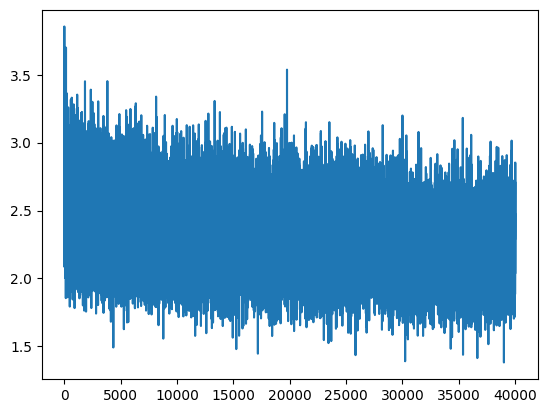

In [61]:
plt.plot(stepi, lossi);

In [80]:
# Validation loss
emb = C[Xdev] # (batch_size, 3, 2)
h = torch.tanh(emb.view(-1,n_embd*block_size) @ W1 + b1) # (batch_size, n_hidden)
logits = h @ W2 + b2 # (batch_size, 27)
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.188725233078003


In [81]:
# Test loss
emb = C[Xte] # (batch_size, 3, 2)
h = torch.tanh(emb.view(-1,n_embd*block_size) @ W1 + b1) # (batch_size, n_hidden)
logits = h @ W2 + b2 # (batch_size, 27)
loss = F.cross_entropy(logits, Yte)
print(loss.item())

2.1889984607696533


In [82]:
# sample from the model
g = torch.Generator(device=device).manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        
        if ix == 0:
            break
            
    print(''.join(itos[i] for i in out))

brentsy.
ezri.
deirandarry.
rersley.
jeid.
jouslee.
emin.
jagrachgeory.
tain.
meth.
breyconi.
abshetze.
ten.
gendyn.
zaz.
raan.
juslana.
dorgh.
davel.
thi.


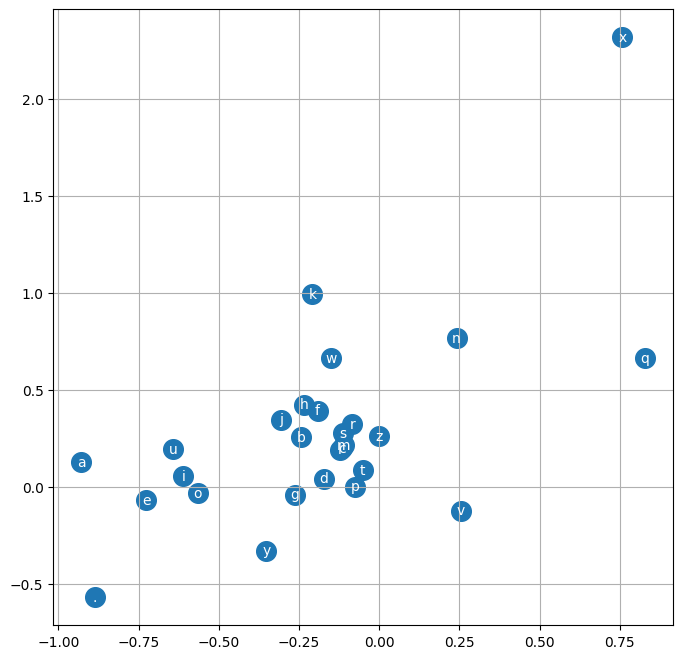

In [83]:
#Let's see if the training affected these embeddings in a meaningful way:
plt.figure(figsize=(8,8))
#plt.scatter(C[:,0].data, C[:,1].data, s=200) - if already on CPU, this is fine, but if on GPU, we need to detach and move to CPU before converting to numpy
plt.scatter(C[:,0].detach().cpu().numpy(), C[:,1].detach().cpu().numpy(), s=200) #GPU to CPU, detach from the graph, convert to numpy
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')

In [71]:
C[0,8].item()

0.25090938806533813